# **Sistema de Clasificación de Imágenes para la Detección del Estado de Salud de Plantas mediante Visión por Computadora**

## Introducción

El presente proyecto tiene como objetivo desarrollar un sistema inteligente basado en técnicas de Visión por Computadora y Machine Learning, capaz de clasificar imágenes de plantas en dos categorías: sanas y marchitas. Esta propuesta surge ante la necesidad del Vivero Casa Blanca ubicado en Arandas, Jalisco, de contar con herramientas accesibles que permitan identificar de manera oportuna el estado de salud de las plantas, ya que, en muchos casos, la detección tardía de enfermedades, falta de riego o condiciones ambientales inadecuadas puede provocar su deterioro irreversible.


## Descripción del dataset

El conjunto de datos estará compuesto por imágenes de plantas clasificadas en dos categorías:

- Plantas sanas
- Plantas marchitas

El dataset estará compuesto por imágenes provenientes de dos fuentes principales:
- Fotografías propias del vivero Casa Blanca, capturadas en condiciones reales.
- Fuentes abiertas en internet, utilizadas para complementar la variabilidad de los datos.

La estructura del dataset será la siguiente:

- Carpeta "sana"
- Carpeta "marchita"

In [ ]:
import os
import matplotlib.pyplot as plt
import cv2

Importacion de las librerías necesarias

## Generación del dataset


Empezamos a recopilar imágenes de plantas reales en los dos estados necesarios para las clases 'sanas' y 'marchitas' para la generación del dataset propio del proyecto.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Se estableció la conexión con Google Drive para acceder al dataset del proyecto, permitiendo trabajar con las imágenes almacenadas de forma organizada y persistente.

In [ ]:
data_dir = "/content/drive/MyDrive/MachineLearning/ProyectoPlantas/dataset"

Se definió la ruta de acceso al dataset, permitiendo localizar las carpetas que contienen las imágenes necesarias para el análisis y procesamiento del proyecto.

In [ ]:
print("Sanas:", len(os.listdir(data_dir + "/sana")))
print("Marchitas:", len(os.listdir(data_dir + "/marchita")))

Sanas: 171
Marchitas: 123


Se verificó la correcta estructura del dataset y la cantidad de imágenes disponibles en cada clase, confirmando que los datos están organizados adecuadamente para su análisis.

## Visualización de datos

En esta sección se presentan ejemplos de imágenes del dataset recolectado, correspondientes a la clase de plantas sanas.

Esta visualización permite analizar las características visuales presentes en las imágenes, lo cual es fundamental para el desarrollo del modelo de clasificación.

In [ ]:
import cv2
import matplotlib.pyplot as plt

def mostrar_imagenes(ruta, titulo):
    imagenes = os.listdir(ruta)

    plt.figure(figsize=(12,6))

    for i in range(min(5, len(imagenes))):
        img_path = os.path.join(ruta, imagenes[i])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(titulo)
    plt.show()

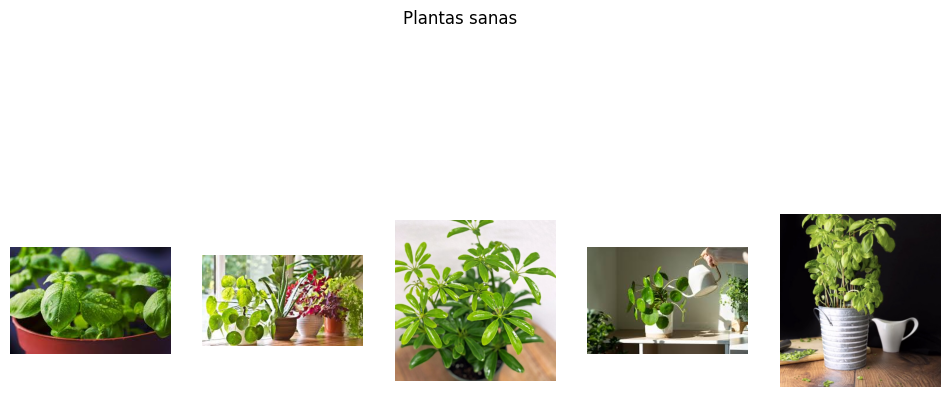

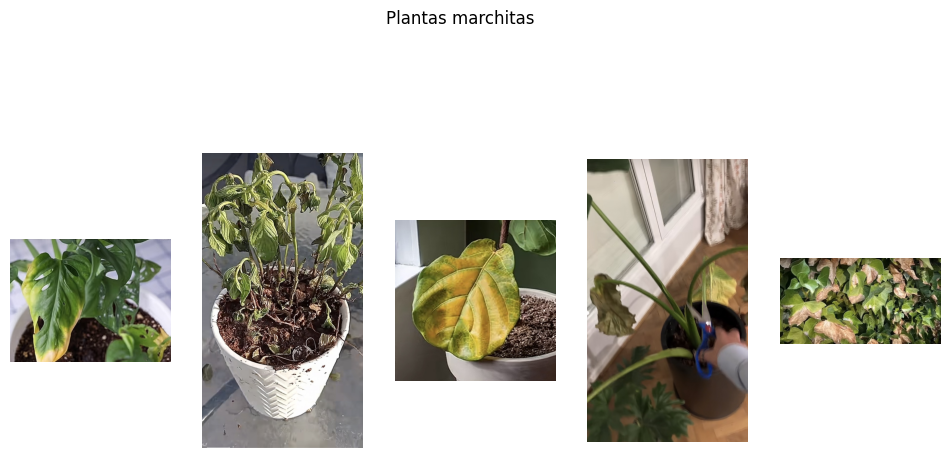

In [ ]:
mostrar_imagenes(data_dir + "/sana", "Plantas sanas")
mostrar_imagenes(data_dir + "/marchita", "Plantas marchitas")

Se implementó una función para visualizar imágenes del dataset, lo cual permite analizar de manera directa las características visuales presentes en las plantas.

## Análisis exploratorio

A partir de la visualización de las imágenes, se identifican características comunes en las plantas sanas, como hojas de color verde intenso, estructuras firmes y una apariencia uniforme.

Se observa que las imágenes presentan variaciones en iluminación y fondo, lo cual puede representar un reto para el modelo, pero también contribuye a que el sistema sea más robusto ante diferentes condiciones.

Se espera que las plantas marchitas presenten diferencias claras, como decoloración, hojas caídas y signos visibles de deterioro, lo que permitirá al modelo diferenciarlas en fases posteriores.

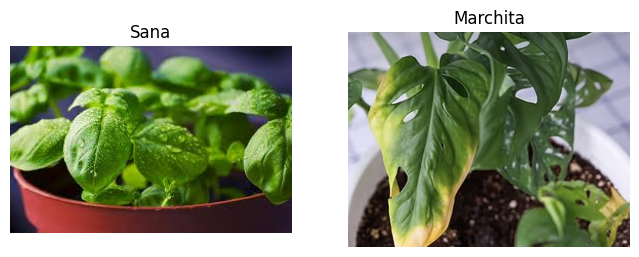

In [ ]:
def comparar_imagenes(ruta1, ruta2):
    img1 = os.listdir(ruta1)[0]
    img2 = os.listdir(ruta2)[0]

    img1 = cv2.imread(os.path.join(ruta1, img1))
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

    img2 = cv2.imread(os.path.join(ruta2, img2))
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.title("Sana")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.title("Marchita")
    plt.axis("off")

    plt.show()

comparar_imagenes(data_dir + "/sana", data_dir + "/marchita")

Se realizó una comparación visual entre imágenes de plantas sanas y marchitas, permitiendo identificar diferencias claras en color y estructura que serán útiles para el modelo de clasificación.

## Análisis exploratorio

A partir de la visualización de las imágenes, se observan diferencias claras entre ambas clases.

Las plantas sanas presentan hojas verdes, firmes y con una estructura uniforme, mientras que las plantas marchitas muestran decoloración, hojas caídas y signos visibles de deterioro.

Estas diferencias visuales permiten establecer que el problema es adecuado para ser abordado mediante técnicas de visión por computadora.

## Definición del problema

Existe la necesidad de identificar de manera automática el estado de salud de una planta a partir de imágenes, con el fin de facilitar su monitoreo y cuidado.

## Naturaleza del problema

El problema abordado corresponde a una tarea de clasificación binaria en visión por computadora, donde el objetivo es asignar una imagen a una de dos clases: planta sana o planta marchita.

## Hipótesis

Un modelo basado en redes neuronales convolucionales (CNN) será capaz de aprender patrones visuales presentes en las imágenes y clasificar correctamente las plantas en sanas o marchitas.

## Métricas de evaluación

Para medir el desempeño del modelo se utilizarán las siguientes métricas:

- Accuracy
- Precision
- Recall
- F1-score

## Valores esperados

- Accuracy ≥ 80%
- Recall ≥ 75%
- F1-score ≥ 75%

## Calidad de datos

Durante el análisis del dataset se identificaron los siguientes posibles problemas:

- Variaciones en iluminación
- Diferentes fondos en las imágenes
- Tamaños de imagen no uniformes

### Outliers
- Imágenes con baja calidad
- Imágenes parcialmente visibles

### Acciones propuestas
- Redimensionamiento de imágenes
- Normalización de valores de píxeles
- Eliminación de imágenes irrelevantes

Exploracion inicial del dataset

In [ ]:
classes = os.listdir(data_dir)
print("Clases encontradas:", classes)

num_classes = len(classes)
print("Número de clases:", num_classes)

Clases encontradas: ['marchita', 'sana']
Número de clases: 2


Se identificaron las clases presentes en el dataset y su cantidad, confirmando la estructura del problema como una tarea de clasificación de imágenes.

In [ ]:
image_count = {}

clases = os.listdir(data_dir)

for clase in clases:
    class_path = os.path.join(data_dir, clase)

    if os.path.isdir(class_path):
        image_count[clase] = len(os.listdir(class_path))

image_count

{'marchita': 123, 'sana': 171}

Se determinó la cantidad de imágenes por cada clase del dataset, lo cual permite analizar la distribución de los datos y detectar posibles desbalances.

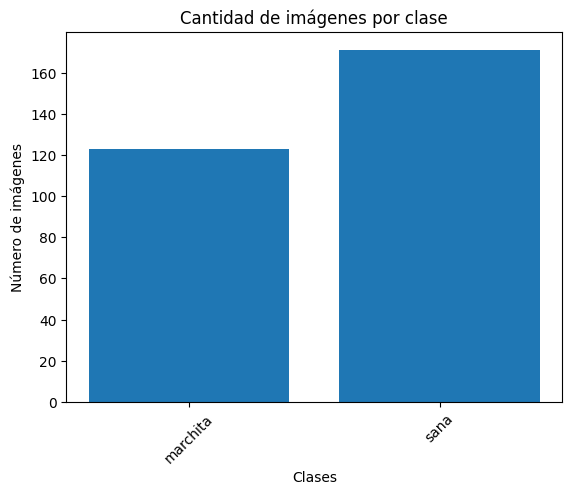

In [ ]:
plt.figure()
plt.bar(image_count.keys(), image_count.values())
plt.xticks(rotation=45)
plt.title("Cantidad de imágenes por clase")
plt.xlabel("Clases")
plt.ylabel("Número de imágenes")
plt.show()

Podemos observar que hay un gran desbalance en la cantidad de imagenes del dataset respecto a la clase de plantas marchitas

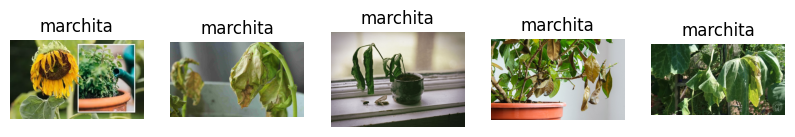

In [ ]:
import random
from PIL import Image

def show_images(clase):
    class_path = os.path.join(data_dir, clase)
    images = os.listdir(class_path)

    plt.figure(figsize=(10,5))

    for i in range(5):
        img_name = random.choice(images)
        img_path = os.path.join(class_path, img_name)

        img = Image.open(img_path)

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.title(clase)
        plt.axis("off")

    plt.show()

# Mostrar imágenes de una clase
show_images(classes[0])

Se visualizaron imágenes aleatorias del dataset, lo que permitió observar la variabilidad presente en una misma clase y comprender mejor la diversidad de los datos.

In [ ]:
sizes = []

clases = os.listdir(data_dir)

for clase in clases:
    class_path = os.path.join(data_dir, clase)


    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            sizes.append(img.size)
        except:
            pass

print(f"Tamaños de las imagenes: {sizes[:10]}")

Tamaños de las imagenes: [(662, 505), (1179, 2168), (504, 504), (1179, 2076), (996, 535), (1179, 2159), (1179, 2071), (1179, 2109), (1171, 1648), (1178, 2142)]


Se analizaron las dimensiones de las imágenes del dataset, identificando variaciones en su tamaño, lo cual indica la necesidad de realizar un proceso de redimensionamiento antes del entrenamiento del modelo.

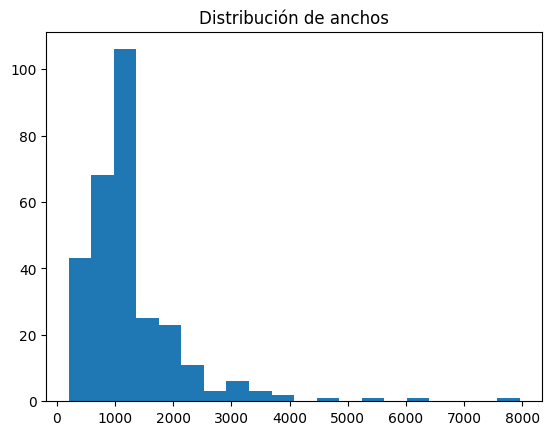

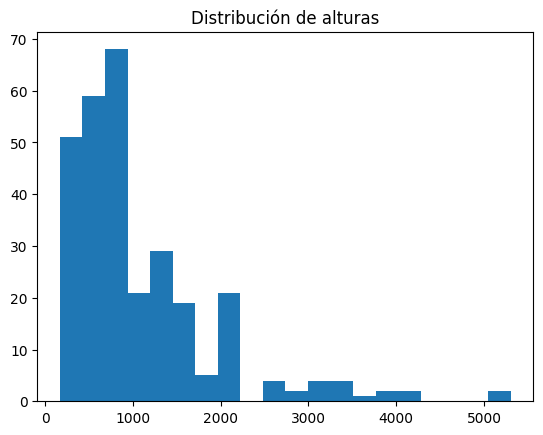

In [ ]:
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.figure()
plt.hist(widths, bins=20)
plt.title("Distribución de anchos")
plt.show()

plt.figure()
plt.hist(heights, bins=20)
plt.title("Distribución de alturas")
plt.show()

Se analizaron las distribuciones de ancho y alto de las imágenes mediante histogramas, lo que permitió visualizar la variabilidad en sus dimensiones.

In [ ]:
corrupt_images = []

clases = ["sana", "marchita"]

for clase in clases:
    class_path = os.path.join(data_dir, clase)

    # Verificar que la carpeta exista
    if not os.path.exists(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupt_images.append(img_path)

print("Imágenes corruptas:", len(corrupt_images))

Imágenes corruptas: 0


La verificación de imágenes corruptas permitió asegurar la integridad del dataset, evitando errores en etapas posteriores y garantizando la calidad de los datos para el entrenamiento del modelo.

In [ ]:
counts = list(image_count.values())

print("Máximo:", max(counts))
print("Mínimo:", min(counts))

Máximo: 171
Mínimo: 123


Se identificaron los valores máximo y mínimo de imágenes por clase, lo que permite evidenciar el nivel de desbalance del dataset.

In [ ]:
total = sum(image_count.values())
print("Total de imágenes en dataset:", total)

Total de imágenes en dataset: 294


Se identificó el número total de imágenes disponibles en el dataset, proporcionando una referencia del tamaño actual y su estado de construcción.

## Conclusión análisis inicial

- El dataset contiene dos clases de plantas: 'sanas' y 'marchitas'.
- Se identificó un desbalance en los datos, ya que la clase 'sanas' contiene una mayor cantidad de imágenes que 'marchitas' DE MOMENTO.
- Se observaron variaciones en el tamaño de las imágenes, lo que indica la necesidad de aplicar técnicas de redimensionamiento.
- No se detectaron imágenes corruptas en el conjunto de datos analizado.
- Será necesario aplicar técnicas de preprocesamiento como:
  - Redimensionamiento
  - Normalización
  - Data augmentation (en etapas posteriores)

Este análisis permite comprender la estructura del dataset y preparar adecuadamente los datos para el entrenamiento de un modelo de clasificación en visión por computadora.

## Conclusión

El análisis exploratorio permitió identificar características visuales relevantes en las imágenes de plantas sanas, como el color y la estructura de las hojas.

El problema abordado corresponde a una tarea de clasificación binaria en visión por computadora, donde se busca diferenciar entre plantas sanas y marchitas.

A pesar de que el dataset aún no está completamente balanceado, se considera adecuado para iniciar el desarrollo de un modelo de clasificación.

Las variaciones en las condiciones de las imágenes representan un desafío, pero también aportan valor al modelo al permitirle generalizar mejor.

En la siguiente fase del proyecto se procederá a completar el dataset y entrenar el modelo de Machine Learning.

# Fase 2 - Limpieza y Transformación de Datos

En esta etapa del proyecto se realizan procesos de limpieza, análisis exploratorio, preprocesamiento e ingeniería de características sobre el dataset de imágenes de plantas sanas y marchitas.

El objetivo es preparar un conjunto de datos uniforme y adecuado para el entrenamiento de un modelo de clasificación basado en visión por computadora.

In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

Se importaron las librerías necesarias para realizar tareas de análisis, procesamiento y visualización de imágenes dentro del pipeline de preprocesamiento.

In [ ]:
data_dir

'/content/drive/MyDrive/MachineLearning/ProyectoPlantas/dataset'

In [ ]:
classes = os.listdir(data_dir)

image_count = {}

for clase in classes:
    class_path = os.path.join(data_dir, clase)

    if os.path.isdir(class_path):
        image_count[clase] = len(os.listdir(class_path))

image_count

{'marchita': 123, 'sana': 171}

Se actualizó el conteo de imágenes por clase después de la ampliación del dataset, permitiendo verificar la nueva distribución de datos disponible para el proyecto.

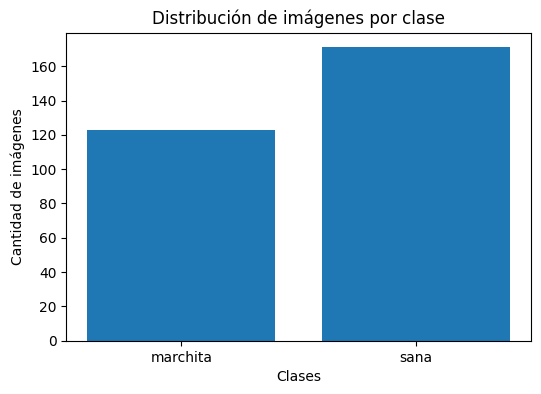

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(image_count.keys(), image_count.values())

plt.title("Distribución de imágenes por clase")
plt.xlabel("Clases")
plt.ylabel("Cantidad de imágenes")

plt.show()

La gráfica permitió visualizar la distribución actual del dataset, identificando un desbalance moderado entre las clases de plantas sanas y marchitas.

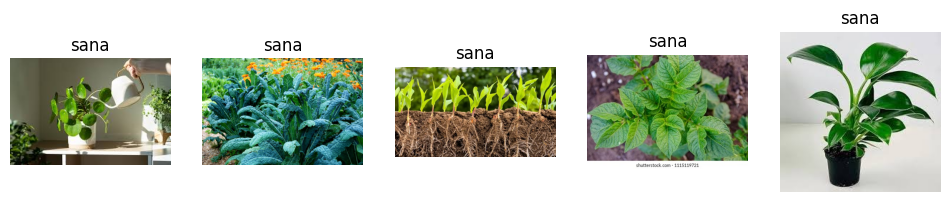

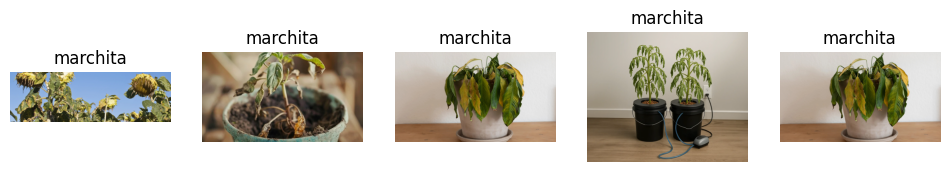

In [ ]:
def mostrar_imagenes(clase):
    class_path = os.path.join(data_dir, clase)

    imagenes = os.listdir(class_path)

    plt.figure(figsize=(12,6))

    for i in range(5):
        img_name = random.choice(imagenes)

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(clase)

    plt.show()

mostrar_imagenes("sana")
mostrar_imagenes("marchita")

La visualización aleatoria de imágenes permitió observar la diversidad presente en el dataset, incluyendo variaciones de iluminación, tamaño, fondo y orientación.

In [ ]:
corrupt_images = []

clases = ["sana", "marchita"]

for clase in clases:

    class_path = os.path.join(data_dir, clase)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()

        except:
            corrupt_images.append(img_path)

print("Imágenes corruptas:", len(corrupt_images))

Imágenes corruptas: 0


Se realizó un proceso de validación para detectar imágenes corruptas dentro del dataset, asegurando la calidad de los datos utilizados en el preprocesamiento.
En este caso no se encontraron imagenes corruptas

In [ ]:
sizes = []

for clase in clases:

    class_path = os.path.join(data_dir, clase)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            sizes.append(img.size)

        except:
            pass

sizes[:10]

[(275, 183),
 (298, 169),
 (570, 570),
 (275, 183),
 (1179, 1273),
 (1179, 2121),
 (1179, 2116),
 (1179, 1332),
 (1179, 1521),
 (1179, 1557)]

### Conclusión

Se analizaron las dimensiones de las imágenes del dataset, identificando variaciones de tamaño que justifican la necesidad de aplicar técnicas de redimensionamiento.

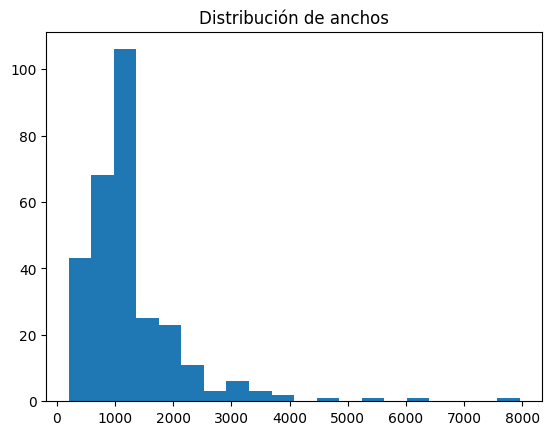

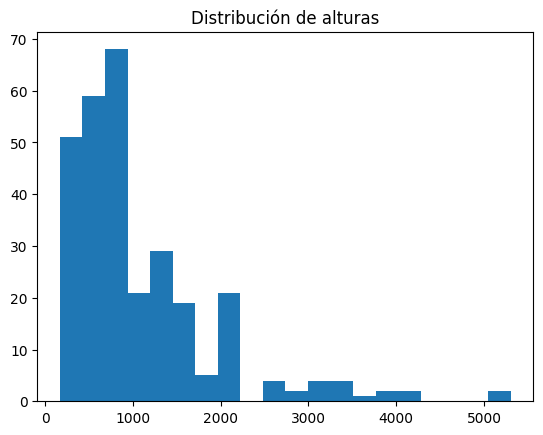

In [ ]:
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.figure()
plt.hist(widths, bins=20)
plt.title("Distribución de anchos")
plt.show()

plt.figure()
plt.hist(heights, bins=20)
plt.title("Distribución de alturas")
plt.show()

Los histogramas permitieron visualizar la variabilidad en las dimensiones de las imágenes, reforzando la necesidad de estandarizar el dataset antes del entrenamiento.

In [ ]:
IMG_SIZE = 128

data = []
labels = []

clases = ["sana", "marchita"]

for clase in clases:

    class_path = os.path.join(data_dir, clase)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        try:
            img = cv2.imread(img_path)

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Redimensionar
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            data.append(img)

            # Etiquetas
            labels.append(clase)

        except:
            pass

print("Imágenes procesadas:", len(data))

Imágenes procesadas: 294


Se realizó el redimensionamiento de las imágenes a un tamaño uniforme de 128x128 píxeles, permitiendo estandarizar los datos de entrada para futuras etapas de entrenamiento del modelo.

In [ ]:
data = np.array(data)
labels = np.array(labels)

print("Shape de imágenes:", data.shape)
print("Shape de etiquetas:", labels.shape)

Shape de imágenes: (294, 128, 128, 3)
Shape de etiquetas: (294,)


Las imágenes y etiquetas fueron convertidas a arreglos de NumPy para facilitar su manipulación y compatibilidad con bibliotecas de Machine Learning.

In [ ]:
#IMPORTANTE NO EJECUTAR ESTA LINEA MAS DE UNA VEZ PARA EVITAR PROBLEMAS DE VISUALIZACION DE LAS IMAGENES
data = data / 255.0

print("Valor mínimo:", data.min())
print("Valor máximo:", data.max())

Valor mínimo: 0.0
Valor máximo: 1.0


Se aplicó un proceso de normalización para escalar los valores de los píxeles entre 0 y 1, mejorando la estabilidad y eficiencia del entrenamiento del modelo.

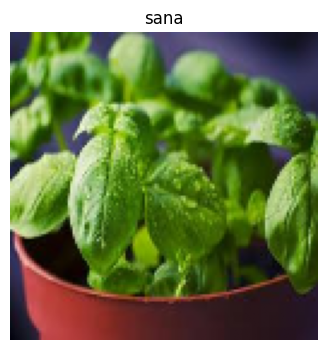

In [ ]:
plt.figure(figsize=(4,4))

plt.imshow(data[0])

plt.title(labels[0])

plt.axis("off")

plt.show()

La visualización de imágenes preprocesadas permitió verificar que el redimensionamiento y normalización fueron aplicados correctamente.

## Data Augmentation
En esta seccion usaremos modificaciones aritificiales a las imagenes para que el modelo aprenda de mejor manera, por ejemplo:
*   Rotaciones
*   Zoom
*   Cambios de brillo
Esto es importante ya que nos ayuda a aumentar artificialmente el dataset, mejora la generalizacion, reduce el overfitting, ayuda con el desbalance del dataset, sobretodo para mejorar las metricas.
Es importante mencionar que no se guardan imagenes nuevas, sino que generamos el entrenamiento/preprocessing

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Se importó la herramienta ImageDataGenerator para aplicar técnicas de aumento de datos sobre las imágenes del dataset.

In [ ]:
datagen = ImageDataGenerator(

    rotation_range=20, #Rotar la imagen
    zoom_range=0.2, #Hacer zoom
    horizontal_flip=True, #Hacer un flip horizontal
    brightness_range=[0.8,1.2] #Cambiar el brillo de la imagen

)

Se configuraron diferentes técnicas de data augmentation para incrementar la variabilidad de las imágenes y mejorar la capacidad de generalización del modelo.

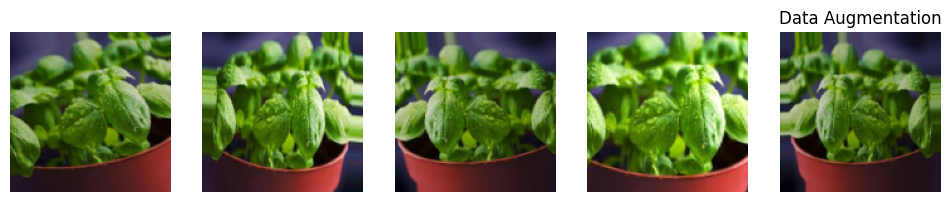

In [ ]:
sample_img = (data[0] * 255).astype(np.uint8)

sample_img = np.expand_dims(sample_img, axis=0)

plt.figure(figsize=(12,6))

i = 0

for batch in datagen.flow(sample_img, batch_size=1):

    plt.subplot(1,5,i+1)

    img = batch[0].astype(np.uint8)

    plt.imshow(img)

    plt.axis("off")

    i += 1

    if i == 5:
        break
plt.title("Data Augmentation")
plt.show()

Se aplicaron técnicas de data augmentation sobre las imágenes del dataset, generando automáticamente nuevas variaciones visuales mediante rotaciones, cambios de brillo, zoom y volteos horizontales.

Estas transformaciones permiten aumentar la diversidad de datos disponibles para el entrenamiento, ayudando a mejorar la capacidad de generalización del modelo y reduciendo el riesgo de sobreajuste.

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

labels_encoded = encoder.fit_transform(labels)

print(labels_encoded[:10])

[1 1 1 1 1 1 1 1 1 1]


Las etiquetas categóricas fueron transformadas a valores numéricos para facilitar su utilización en algoritmos de Machine Learning.

## Division Train/Test
Separaremos: datos de entrenamiento y datos de prueba
Esto es MUY importante para evaluar correctamente el modelo después.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels_encoded,
    test_size=0.2,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (235, 128, 128, 3)
Prueba: (59, 128, 128, 3)


El dataset fue dividido en conjuntos de entrenamiento y prueba, permitiendo evaluar posteriormente el desempeño del modelo utilizando datos no vistos durante el entrenamiento.

El conjunto de entrenamiento contiene 235 imágenes utilizadas para el aprendizaje del modelo, mientras que el conjunto de prueba contiene 59 imágenes destinadas a evaluar el desempeño del sistema sobre datos no vistos previamente.

Cada imagen fue redimensionada a 128x128 píxeles y conserva sus 3 canales de color RGB.

In [ ]:
print("Imágenes entrenamiento:", len(X_train))
print("Imágenes prueba:", len(X_test))

Imágenes entrenamiento: 235
Imágenes prueba: 59


Se verificó correctamente la distribución final del dataset, asegurando la disponibilidad de datos suficientes para entrenamiento y validación del modelo.

# Conclusión Segunda Fase:

Durante el desarrollo de esta segunda fase del proyecto se construyó un pipeline de análisis, limpieza y preprocesamiento de datos enfocado en imágenes de plantas sanas y marchitas.

Inicialmente se realizó una exploración general del dataset para identificar la cantidad de imágenes disponibles, la distribución entre clases y las principales características visuales presentes en las imágenes. Este análisis permitió detectar un desbalance moderado entre categorías, así como variaciones en dimensiones, iluminación, orientación y fondos.

Posteriormente se llevaron a cabo procesos de validación y limpieza de datos, incluyendo la detección de imágenes corruptas y la verificación de la estructura de carpetas dentro de Google Drive y Google Colab, con el objetivo de asegurar la integridad y correcta organización del dataset.

Como parte del preprocesamiento, todas las imágenes fueron redimensionadas a un tamaño uniforme de 128x128 píxeles y normalizadas en un rango de valores entre 0 y 1, permitiendo estandarizar los datos y prepararlos para futuras etapas de entrenamiento del modelo.

Asimismo, se implementaron técnicas de data augmentation mediante rotaciones, zoom, cambios de brillo y volteos horizontales, incrementando artificialmente la variabilidad del dataset y mejorando potencialmente la capacidad de generalización del modelo frente a nuevos datos.

Finalmente, las etiquetas fueron transformadas a valores numéricos y el dataset fue dividido en conjuntos de entrenamiento y prueba, dejando los datos completamente preparados para las siguientes etapas del proyecto relacionadas con el entrenamiento, validación y evaluación del modelo de Machine Learning.

#Fase 3 de Proyecto

In [ ]:
print("Clases del encoder:", encoder.classes_)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Clases del encoder: ['marchita' 'sana']
X_train: (235, 128, 128, 3)
X_test: (59, 128, 128, 3)
y_train: (235,)
y_test: (59,)


Se verificó la estructura final del dataset después del preprocesamiento, confirmando la cantidad de imágenes destinadas al entrenamiento y prueba, así como las clases utilizadas por el modelo.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Se construyó una red neuronal convolucional (CNN) para clasificar imágenes de plantas sanas y marchitas. Además, se integró data augmentation dentro del modelo para aumentar la variabilidad de los datos durante el entrenamiento y reducir el riesgo de sobreajuste.

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=16,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 652ms/step - accuracy: 0.5532 - loss: 0.7859 - val_accuracy: 0.5932 - val_loss: 0.6753 - learning_rate: 0.0010
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 681ms/step - accuracy: 0.5191 - loss: 0.7024 - val_accuracy: 0.5932 - val_loss: 0.6190 - learning_rate: 0.0010
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 496ms/step - accuracy: 0.5787 - loss: 0.6151 - val_accuracy: 0.6949 - val_loss: 0.5533 - learning_rate: 0.0010
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 629ms/step - accuracy: 0.6894 - loss: 0.5865 - val_accuracy: 0.7797 - val_loss: 0.5344 - learning_rate: 0.0010
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 483ms/step - accuracy: 0.7191 - loss: 0.5700 - val_accuracy: 0.7797 - val_loss: 0.5121 - learning_rate: 0.0010
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 537ms/step - accuracy: 0.7149 - loss: 0.5868 - val_accuracy: 0.7119 - val_loss: 0.5302 - learning_rate: 0.0010
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 617ms/step - accuracy: 0.7149 - loss: 0.548

Se entrenó el modelo utilizando el conjunto de entrenamiento y se validó con el conjunto de prueba. También se aplicaron callbacks como EarlyStopping y ReduceLROnPlateau para mejorar el proceso de entrenamiento, evitar sobreajuste y ajustar la tasa de aprendizaje automáticamente.

In [ ]:
# Evaluacion del modelo
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 457ms/step - accuracy: 0.8475 - loss: 0.3914
Loss: 0.3913796544075012
Accuracy: 0.8474576473236084


Se evaluó el modelo con datos no vistos durante el entrenamiento, obteniendo los valores de pérdida y exactitud. Estos resultados permiten conocer el desempeño inicial del modelo para clasificar plantas sanas y marchitas.

In [ ]:
# Guardamos el modelo
model.save("modelo_plantas.keras")

In [ ]:
# conectarse a Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Ruta para guardar el modelo
model_path = '/content/drive/MyDrive/MachineLearning/ProyectoPlantas/modelo_plantas.keras'
model.save(model_path)

El modelo entrenado fue guardado en formato `.keras`, permitiendo reutilizarlo posteriormente en una aplicación web para realizar predicciones con nuevas imágenes.

In [ ]:
from google.colab import files
files.download("modelo_plantas.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Clases del encoder:", encoder.classes_)

Clases del encoder: ['marchita' 'sana']


## Pruebas

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving imgi_127_cc73b6d3-857f-4250-af3c-36f574956815.jpg to imgi_127_cc73b6d3-857f-4250-af3c-36f574956815.jpg


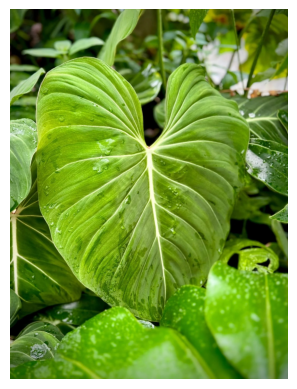

Shape: (1, 128, 128, 3)


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Obtener el nombre del archivo subido
img_path = list(uploaded.keys())[0]

# Mostrar imagen original
img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()

# Redimensionar a 128x128
img_resized = img.resize((128, 128))

# Convertir a arreglo y normalizar
img_array = np.array(img_resized) / 255.0

# Agregar dimensión batch
img_array = np.expand_dims(img_array, axis=0)

print("Shape:", img_array.shape)

In [ ]:
prediction = model.predict(img_array)[0][0]

print("Probabilidad:", prediction)

if prediction >= 0.5:
    print("🌿 Resultado: Planta sana")
else:
    print("🥀 Resultado: Planta marchita")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Probabilidad: 0.97894025
🌿 Resultado: Planta sana


In [ ]:
if prediction >= 0.5:
    confianza = prediction * 100
    print(f"🌿 Planta sana ({confianza:.2f}% de confianza)")
else:
    confianza = (1 - prediction) * 100
    print(f"🥀 Planta marchita ({confianza:.2f}% de confianza)")

🌿 Planta sana (97.89% de confianza)


Se realizó una prueba del modelo con una imagen externa, verificando que es capaz de cargar, procesar y clasificar nuevas imágenes como plantas sanas o marchitas, mostrando además un porcentaje de confianza en la predicción.

In [64]:
model.save_weights("modelo_plantas.weights.h5")

In [65]:
from google.colab import files
files.download("modelo_plantas.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>